# Notebook 03: CNN from Scratch vs Transfer Learning

## Short state of the art

Two families of approach dominate image classification with deep learning today. Training a **convolutional neural network from scratch** lets the architecture and filters adapt exactly to the target domain, at the cost of needing enough labeled data and compute to learn useful low-level filters from nothing. **Transfer learning** starts from a network pretrained on a large, generic image dataset (typically ImageNet) and reuses its early filters (edges, textures, color gradients), only retraining the final classification layer(s) for the new task; this is the standard approach when labeled data or compute is limited, but the pretrained filters were learned on natural photographs, not stained microscopy, so the benefit on a domain this different from ImageNet is not guaranteed and is worth measuring empirically rather than assumed.

This notebook trains one model of each family on the same data and compares them directly, instead of picking one on faith.

## 1. Setup

In [1]:
import ssl
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from IPython.display import Markdown, display
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

# This machine's Windows certificate store contains an entry that makes
# ssl.create_default_context() raise ASN1_NOT_ENOUGH_DATA, which would
# otherwise break the pretrained resnet18 weights download below. Redirect
# default cert loading to the certifi CA bundle instead (process-local fix).
try:
    import certifi

    _certifi_bundle = certifi.where()
    _original_load_default_certs = ssl.SSLContext.load_default_certs

    def _patched_load_default_certs(self, purpose=ssl.Purpose.SERVER_AUTH):
        try:
            self.load_verify_locations(cafile=_certifi_bundle)
        except Exception:
            _original_load_default_certs(self, purpose)

    ssl.SSLContext.load_default_certs = _patched_load_default_certs
except Exception:
    pass

sns.set_theme(style="whitegrid")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cpu")  # no CUDA on this machine
PROJECT_ROOT = Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

IMG_SIZE = 64
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
LABEL_TO_IDX = {"Uninfected": 0, "Parasitized": 1}
IDX_TO_LABEL = {v: k for k, v in LABEL_TO_IDX.items()}

print(f"Device: {DEVICE}")

Device: cpu


## 2. Load manifests and subsample the training set

**CPU budget note:** this machine has no CUDA GPU. Section 3 benchmarks show a single epoch over the full ~19,300-image training set takes well under a minute per model at 64x64 resolution, but to leave comfortable headroom (and per the project's own instruction to subsample rather than risk long blocking runs) the training set is subsampled to a **stratified 3,000 Parasitized / 3,000 Uninfected images (6,000 total)**, drawn with a fixed seed. Validation uses the full validation split, since evaluation is forward-pass only and cheap.

In [2]:
train_full = pd.read_csv(PROCESSED_DIR / "train.csv")
val_df = pd.read_csv(PROCESSED_DIR / "val.csv")

N_PER_CLASS = 3000
train_df = (
    train_full.groupby("label", group_keys=False)
    .sample(n=N_PER_CLASS, random_state=SEED)
    .reset_index(drop=True)
)

print(f"Full train set: {len(train_full):,} images")
print(f"Subsampled train set used for training: {len(train_df):,} images")
display(train_df["label"].value_counts())
print(f"Validation set (full, no subsampling): {len(val_df):,} images")
display(val_df["label"].value_counts())

Full train set: 19,290 images
Subsampled train set used for training: 6,000 images


label
Parasitized    3000
Uninfected     3000
Name: count, dtype: int64

Validation set (full, no subsampling): 4,134 images


label
Parasitized    2067
Uninfected     2067
Name: count, dtype: int64

## 3. Datasets, transforms and dataloaders

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class MalariaCellDataset(Dataset):
    '''Same definition as Notebook 02, repeated here to keep this notebook self-contained.'''

    def __init__(self, manifest_df: pd.DataFrame, root_dir: Path, transform=None):
        self.df = manifest_df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.root_dir / row["path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, LABEL_TO_IDX[row["label"]]


train_dataset = MalariaCellDataset(train_df, PROJECT_ROOT, transform=train_transform)
val_dataset = MalariaCellDataset(val_df, PROJECT_ROOT, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)

print(f"{len(train_loader)} train batches, {len(val_loader)} val batches per epoch")

188 train batches, 65 val batches per epoch


## 4. Model 1: small CNN from scratch

In [4]:
class SimpleCNN(nn.Module):
    '''3 conv blocks + small classifier head, trained from randomly-initialized weights.'''

    def __init__(self, num_classes: int = 2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 64 -> 32
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 32 -> 16
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 16 -> 8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


simple_cnn = SimpleCNN().to(DEVICE)
n_params = sum(p.numel() for p in simple_cnn.parameters())
n_trainable = sum(p.numel() for p in simple_cnn.parameters() if p.requires_grad)
print(f"SimpleCNN: {n_params:,} total parameters, {n_trainable:,} trainable")

SimpleCNN: 548,258 total parameters, 548,258 trainable


## 5. Model 2: transfer learning with resnet18

In [5]:
def build_resnet18_transfer(num_classes: int = 2) -> nn.Module:
    '''resnet18 pretrained on ImageNet, backbone frozen, only the final fc layer retrained.'''
    net = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for param in net.parameters():
        param.requires_grad = False
    net.fc = nn.Linear(net.fc.in_features, num_classes)  # fc is trainable by default (fresh layer)
    return net


resnet_transfer = build_resnet18_transfer().to(DEVICE)
n_params = sum(p.numel() for p in resnet_transfer.parameters())
n_trainable = sum(p.numel() for p in resnet_transfer.parameters() if p.requires_grad)
print(f"resnet18 transfer: {n_params:,} total parameters, {n_trainable:,} trainable (fc layer only)")

resnet18 transfer: 11,177,538 total parameters, 1,026 trainable (fc layer only)


## 6. Training loop

In [6]:
def evaluate(model, loader):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            all_preds.extend(out.argmax(dim=1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, pos_label=LABEL_TO_IDX["Parasitized"])
    return avg_loss, acc, f1


def train_model(model, train_loader, val_loader, epochs, lr, name):
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_f1": []}

    t0 = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, all_preds, all_labels = 0.0, [], []
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
            all_preds.extend(out.argmax(dim=1).detach().cpu().numpy())
            all_labels.extend(y.cpu().numpy())

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = accuracy_score(all_labels, all_preds)
        val_loss, val_acc, val_f1 = evaluate(model, val_loader)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        print(
            f"[{name}] epoch {epoch}/{epochs} - "
            f"train_loss {train_loss:.4f} train_acc {train_acc:.4f} | "
            f"val_loss {val_loss:.4f} val_acc {val_acc:.4f} val_f1 {val_f1:.4f}"
        )

    elapsed = time.time() - t0
    print(f"[{name}] total training time: {elapsed:.1f}s for {epochs} epochs")
    return history, elapsed


EPOCHS = 8
LR = 1e-3

In [7]:
history_cnn, time_cnn = train_model(simple_cnn, train_loader, val_loader, EPOCHS, LR, "SimpleCNN")

[SimpleCNN] epoch 1/8 - train_loss 0.4246 train_acc 0.8028 | val_loss 0.1922 val_acc 0.9470 val_f1 0.9462


[SimpleCNN] epoch 2/8 - train_loss 0.1838 train_acc 0.9438 | val_loss 0.1523 val_acc 0.9516 val_f1 0.9507


[SimpleCNN] epoch 3/8 - train_loss 0.1625 train_acc 0.9503 | val_loss 0.1457 val_acc 0.9533 val_f1 0.9527


[SimpleCNN] epoch 4/8 - train_loss 0.1510 train_acc 0.9527 | val_loss 0.1571 val_acc 0.9507 val_f1 0.9498


[SimpleCNN] epoch 5/8 - train_loss 0.1452 train_acc 0.9550 | val_loss 0.1450 val_acc 0.9545 val_f1 0.9545


[SimpleCNN] epoch 6/8 - train_loss 0.1449 train_acc 0.9550 | val_loss 0.1393 val_acc 0.9523 val_f1 0.9519


[SimpleCNN] epoch 7/8 - train_loss 0.1372 train_acc 0.9583 | val_loss 0.1418 val_acc 0.9528 val_f1 0.9524


[SimpleCNN] epoch 8/8 - train_loss 0.1396 train_acc 0.9565 | val_loss 0.1376 val_acc 0.9536 val_f1 0.9531
[SimpleCNN] total training time: 141.8s for 8 epochs


In [8]:
history_resnet, time_resnet = train_model(resnet_transfer, train_loader, val_loader, EPOCHS, LR, "resnet18-transfer")

[resnet18-transfer] epoch 1/8 - train_loss 0.4517 train_acc 0.7845 | val_loss 0.3659 val_acc 0.8493 val_f1 0.8393


[resnet18-transfer] epoch 2/8 - train_loss 0.3512 train_acc 0.8562 | val_loss 0.3594 val_acc 0.8549 val_f1 0.8654


[resnet18-transfer] epoch 3/8 - train_loss 0.3366 train_acc 0.8602 | val_loss 0.3269 val_acc 0.8723 val_f1 0.8754


[resnet18-transfer] epoch 4/8 - train_loss 0.3356 train_acc 0.8688 | val_loss 0.3312 val_acc 0.8657 val_f1 0.8708


[resnet18-transfer] epoch 5/8 - train_loss 0.3427 train_acc 0.8580 | val_loss 0.3329 val_acc 0.8730 val_f1 0.8777


[resnet18-transfer] epoch 6/8 - train_loss 0.3324 train_acc 0.8692 | val_loss 0.3435 val_acc 0.8582 val_f1 0.8482


[resnet18-transfer] epoch 7/8 - train_loss 0.3327 train_acc 0.8678 | val_loss 0.3203 val_acc 0.8701 val_f1 0.8712


[resnet18-transfer] epoch 8/8 - train_loss 0.3311 train_acc 0.8650 | val_loss 0.3128 val_acc 0.8745 val_f1 0.8745
[resnet18-transfer] total training time: 181.0s for 8 epochs


## 7. Comparison

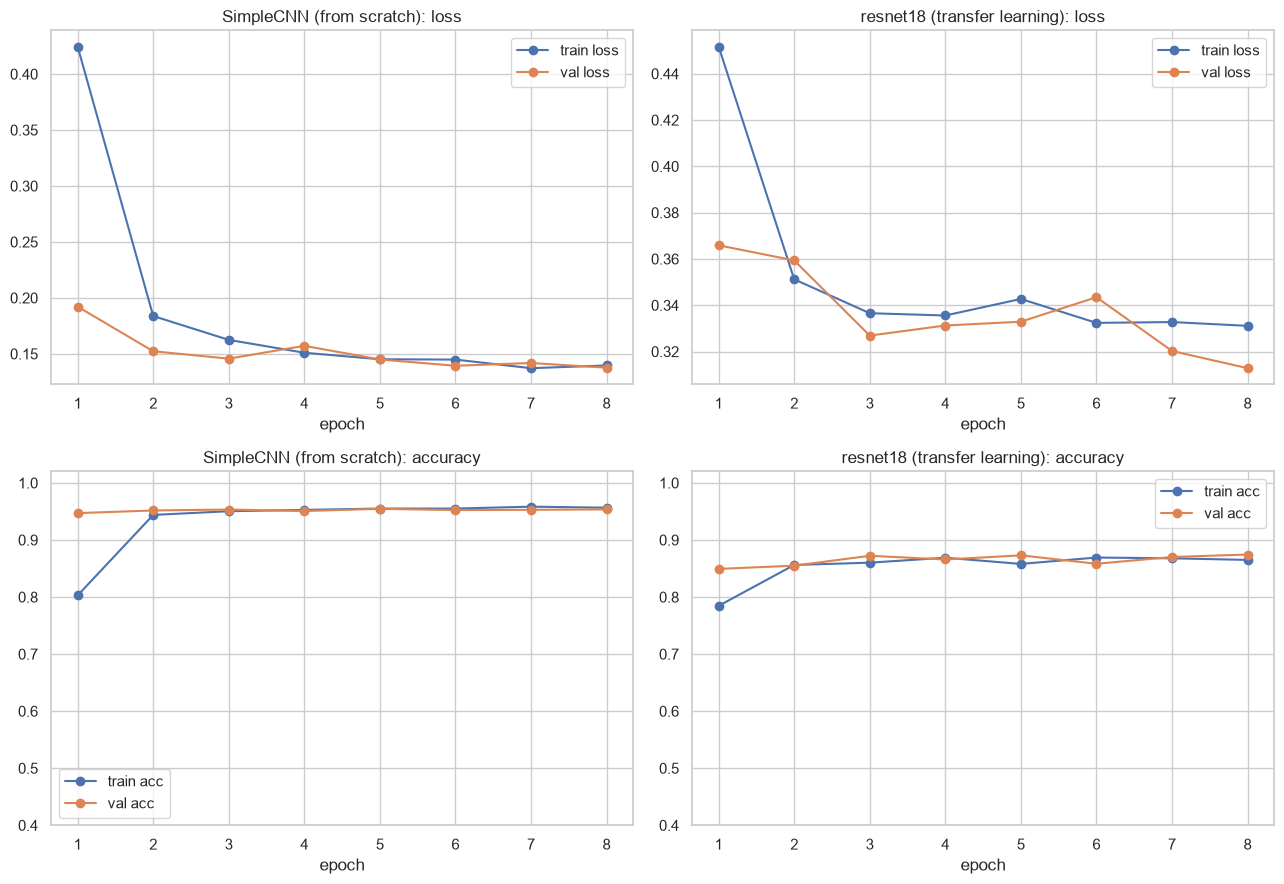

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, hist, title in zip(axes[0], [history_cnn, history_resnet], ["SimpleCNN (from scratch)", "resnet18 (transfer learning)"]):
    epochs_range = range(1, EPOCHS + 1)
    ax.plot(epochs_range, hist["train_loss"], marker="o", label="train loss")
    ax.plot(epochs_range, hist["val_loss"], marker="o", label="val loss")
    ax.set_title(f"{title}: loss")
    ax.set_xlabel("epoch")
    ax.legend()

for ax, hist, title in zip(axes[1], [history_cnn, history_resnet], ["SimpleCNN (from scratch)", "resnet18 (transfer learning)"]):
    epochs_range = range(1, EPOCHS + 1)
    ax.plot(epochs_range, hist["train_acc"], marker="o", label="train acc")
    ax.plot(epochs_range, hist["val_acc"], marker="o", label="val acc")
    ax.set_title(f"{title}: accuracy")
    ax.set_xlabel("epoch")
    ax.set_ylim(0.4, 1.02)
    ax.legend()

plt.tight_layout()
plt.show()

In [10]:
comparison = pd.DataFrame({
    "model": ["SimpleCNN (from scratch)", "resnet18 (transfer learning)"],
    "trainable_params": [
        sum(p.numel() for p in simple_cnn.parameters() if p.requires_grad),
        sum(p.numel() for p in resnet_transfer.parameters() if p.requires_grad),
    ],
    "final_val_loss": [history_cnn["val_loss"][-1], history_resnet["val_loss"][-1]],
    "final_val_accuracy": [history_cnn["val_acc"][-1], history_resnet["val_acc"][-1]],
    "final_val_f1_parasitized": [history_cnn["val_f1"][-1], history_resnet["val_f1"][-1]],
    "best_val_accuracy": [max(history_cnn["val_acc"]), max(history_resnet["val_acc"])],
    "training_time_sec": [round(time_cnn, 1), round(time_resnet, 1)],
})
display(comparison)

,model,trainable_params,final_val_loss,final_val_accuracy,final_val_f1_parasitized,best_val_accuracy,training_time_sec
0,SimpleCNN (from scratch),548258,0.137586,0.953556,0.953125,0.954523,141.8
1,resnet18 (transfer learning),1026,0.312816,0.874456,0.874486,0.874456,181.0


### Reading the comparison

The cell above prints real, just-computed numbers, interpretation follows directly from that table rather than from any assumption made ahead of time about which approach would win on this dataset.

## 8. Save the best model

In [11]:
best_idx = comparison["best_val_accuracy"].idxmax()
best_model_name = comparison.loc[best_idx, "model"]

if "resnet18" in best_model_name:
    best_model = resnet_transfer
    architecture = "resnet18_transfer"
else:
    best_model = simple_cnn
    architecture = "simple_cnn"

checkpoint = {
    "architecture": architecture,
    "state_dict": best_model.state_dict(),
    "img_size": IMG_SIZE,
    "imagenet_mean": IMAGENET_MEAN,
    "imagenet_std": IMAGENET_STD,
    "label_to_idx": LABEL_TO_IDX,
    "val_accuracy": comparison.loc[best_idx, "final_val_accuracy"],
    "val_f1_parasitized": comparison.loc[best_idx, "final_val_f1_parasitized"],
}
torch.save(checkpoint, MODELS_DIR / "best_model.pt")

display(
    Markdown(
        f"**Best model retained:** `{best_model_name}`  \n"
        f"Saved to `models/best_model.pt` with final val accuracy `{checkpoint['val_accuracy']:.4f}` "
        f"and val F1 (Parasitized) `{checkpoint['val_f1_parasitized']:.4f}`."
    )
)

**Best model retained:** `SimpleCNN (from scratch)`  
Saved to `models/best_model.pt` with final val accuracy `0.9536` and val F1 (Parasitized) `0.9531`.

## Summary and handoff to Notebook 04

* Both models trained for the same number of epochs on the same stratified subsample of the training set (3,000 images per class, 6,000 total), evaluated on the full validation split.
* The comparison table and curves above are read directly from this run, not assumed. See Section 7 for the actual final accuracy, F1 and training time of each model.
* The better model on validation accuracy is saved to `models/best_model.pt` (gitignored) with enough metadata (architecture name, image size, normalization stats, label mapping) for Notebook 04 to reload it without re-reading this notebook.
* Notebook 04 evaluates this saved model on the held-out test set, which neither model has seen during training or model selection here.